In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
sys.path.append("./morphomnist") 

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from prepare_data import prepare_flow_data, unflatten, inverse_logit

# Data preparation

In [3]:

SIZE = 8
data = prepare_flow_data("morphomnist/data/", size=SIZE, seed=0)

In [4]:
Z = np.asarray(data["Z"])        # shape (n, 11): [thickness, digit_onehot(10)]
digit_onehot = Z[:, 1:]          # (n, 10)
labels = np.argmax(digit_onehot, axis=1)
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))
# digit-0 count:
print("digit 0 count:", (labels == 0).sum())

{np.int64(0): np.int64(5923), np.int64(1): np.int64(6742), np.int64(2): np.int64(5958), np.int64(3): np.int64(6131), np.int64(4): np.int64(5842), np.int64(5): np.int64(5421), np.int64(6): np.int64(5918), np.int64(7): np.int64(6265), np.int64(8): np.int64(5851), np.int64(9): np.int64(5949)}
digit 0 count: 5923


In [5]:
# Start from the existing prepared Morphomnist data
# `data["Z"][:,1]` is the digit label, so zeros are digit 0
zero_idx = np.where(Z[:, 1] == 1)[0]   # column 1 equals 1 means digit == 0


In [6]:
data["Z"].shape

(60000, 11)

In [7]:
zero_idx.shape

(5923,)

In [8]:
#N=1000 # If you want exactly N zeros
#sel = rng.choice(zero_idx, N, replace=False)  # choose a smaller toy subset

Y0 = np.asarray(data["Y0"])[zero_idx]          # untreated images in flow space
Z0 = np.asarray(data["Z"])[zero_idx]           # covariate/digit info
seed = 123
rng = np.random.default_rng(seed)

In [9]:
# Random treatment assignment for a clean toy experiment
X = (rng.uniform(size=len(Y0)) < 0.5).astype(np.float64)[:, None]

# Define a fixed central white circle effect in pixel space
size = 8
xx, yy = np.meshgrid(np.arange(size), np.arange(size), indexing="ij")
radius = 2
circle = ((xx - (size - 1) / 2) ** 2 + (yy - (size - 1) / 2) ** 2 <= radius**2).astype(np.float64)

# Choose the effect magnitude in logit space
circle_flat = circle.reshape(1, -1)         # (1, 64)
base_shift = 1.0
ITE = base_shift * circle_flat              # (1,64) -> will broadcast to (n,64)
Y1 = Y0 + ITE                               # broadcasts correctly
Y = np.where(X == 1, Y1, Y0)

toy_data = {
    "Y": jnp.asarray(Y),
    "X": jnp.asarray(X),
    "Z": jnp.asarray(Z0)[:,0],
    "Y0": jnp.asarray(Y0),
    "Y1": jnp.asarray(Y1),
    "ITE": jnp.asarray(ITE),
    "ATE": jnp.asarray(ITE.mean(axis=0)),
}

max |ITE|: 1.0
nonzero fraction: 0.1875
per-unit nonzero pixels: [12]


Text(0.5, 1.0, 'mean |ITE| per pixel')

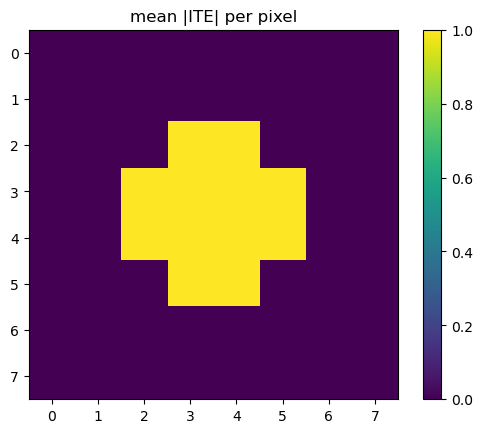

In [10]:
ITE = np.asarray(toy_data["ITE"])
print("max |ITE|:", np.abs(ITE).max())
print("nonzero fraction:", (ITE != 0).mean())          # expect roughly the ink fraction, ~0.15–0.3
print("per-unit nonzero pixels:", (ITE != 0).sum(axis=1)[:10])
plt.imshow(np.abs(ITE).mean(axis=0).reshape(SIZE, SIZE)); plt.colorbar()
plt.title("mean |ITE| per pixel")  # should light up where digits are

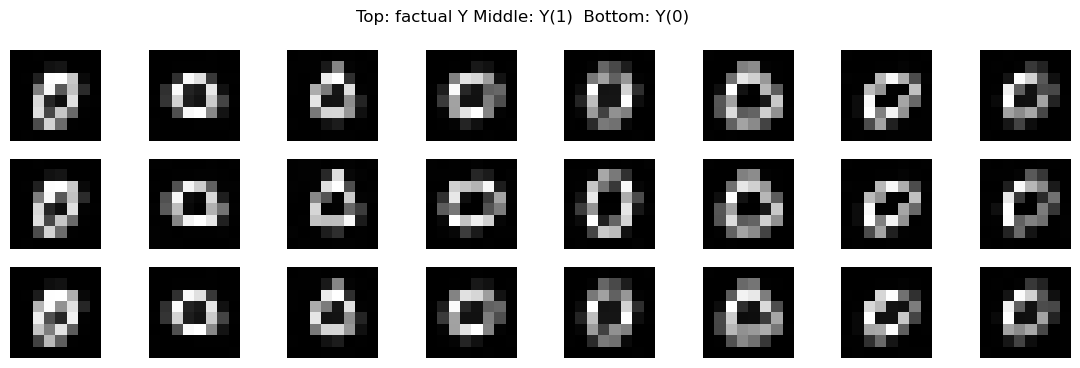

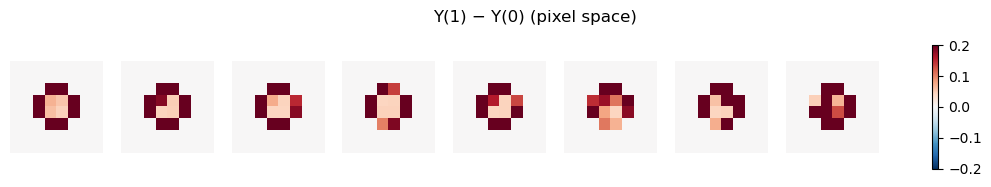

In [11]:
fig, axes = plt.subplots(3, 8, figsize=(14, 4))
imgs = inverse_logit(np.asarray(toy_data["Y"][:8]))          # back to [0,1]
for i, ax in enumerate(axes[0]):
    ax.imshow(unflatten(imgs[i], SIZE)[0], cmap="gray"); ax.axis("off")
axes[0, 0].set_ylabel("factual", rotation=0)

# untreated potential outcome for the same units
imgs0 = inverse_logit(np.asarray(toy_data["Y0"][:8]))
for i, ax in enumerate(axes[1]):
    ax.imshow(unflatten(imgs0[i], SIZE)[0], cmap="gray"); ax.axis("off")

# treated potential outcome for the same units
imgs1 = inverse_logit(np.asarray(toy_data["Y1"][:8]))
for i, ax in enumerate(axes[2]):
    ax.imshow(unflatten(imgs1[i], SIZE)[0], cmap="gray"); ax.axis("off")
plt.suptitle("Top: factual Y Middle: Y(1)  Bottom: Y(0)")
plt.show()


T = np.asarray(toy_data["X"]).flatten().astype(bool)
diff = inverse_logit(np.asarray(toy_data["Y1"])) - inverse_logit(np.asarray(toy_data["Y0"]))

idx = np.where(T)[0][:8]
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in zip(idx, axes):
    im = ax.imshow(diff[i].reshape(SIZE, SIZE), cmap="RdBu_r",
                   vmin=-0.2, vmax=0.2)
    ax.axis("off")
plt.suptitle("Y(1) − Y(0) (pixel space)")
plt.colorbar(im, ax=axes, shrink=0.8)
plt.show()

In [12]:
np.asarray(toy_data["Z"])

array([ 0.00299724, -0.45106363, -0.5138827 , ..., -0.28759843,
       -0.1749392 , -0.5549794 ], shape=(5923,), dtype=float32)

treated fraction: 0.503


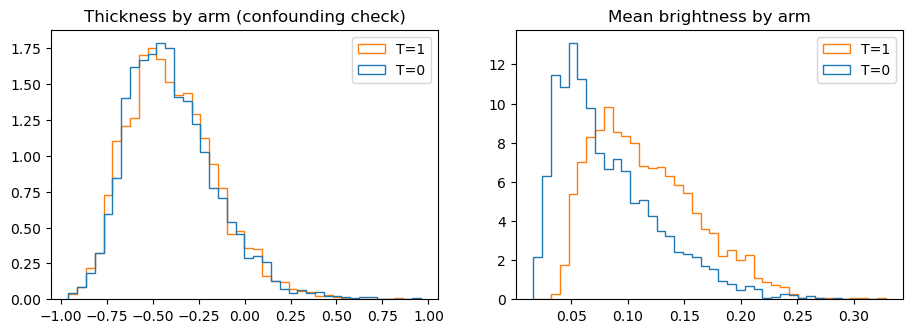

In [13]:
T = np.asarray(toy_data["X"]).flatten()
thickness = np.asarray(toy_data["Z"])
print(f"treated fraction: {T.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist([thickness[T==0], thickness[T==1]], bins=40, label=["T=0", "T=1"], density=True, histtype="step")
axes[0].legend(); axes[0].set_title("Thickness by arm (confounding check)")

# naive vs adjusted difference in mean brightness
mean_bright = inverse_logit(toy_data["Y"]).mean(axis=1)
axes[1].hist([mean_bright[T==0], mean_bright[T==1]], bins=40, label=["T=0", "T=1"], density=True, histtype="step")
axes[1].legend(); axes[1].set_title("Mean brightness by arm")
plt.show()

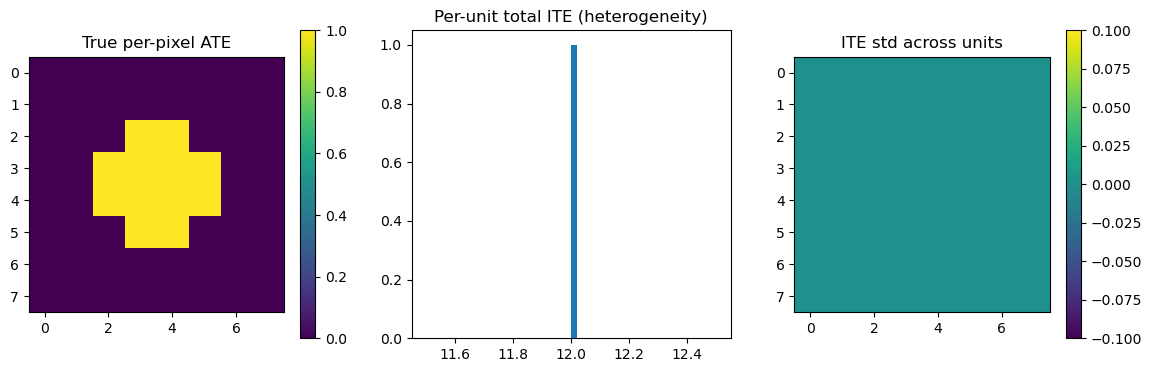

In [14]:
ATE = np.asarray(toy_data["ATE"])           # (K,)
ITE = np.asarray(toy_data["ITE"])           # (n, K)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im = axes[0].imshow(ATE.reshape(SIZE, SIZE)); plt.colorbar(im, ax=axes[0])
axes[0].set_title("True per-pixel ATE")

axes[1].hist(ITE.sum(axis=1), bins=50)
axes[1].set_title("Per-unit total ITE (heterogeneity)")

im = axes[2].imshow(ITE.std(axis=0).reshape(SIZE, SIZE)); plt.colorbar(im, ax=axes[2])
axes[2].set_title("ITE std across units")
plt.show()

In [15]:
toy_data["Z"].shape


(5923,)

## Frugal flow location translation

In [16]:
import equinox as eqx
import inspect
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import frugal_flows

from frugal_flows.basic_flows import (masked_independent_flow, 
                                        masked_autoregressive_flow_first_uniform, 
                                        masked_autoregressive_flow_masked_cond)
from frugal_flows.bijections import UnivariateNormalCDF
from frugal_flows.causal_flows import (train_frugal_flow, 
                                        train_frugal_flow_location_translation,
                                        train_copula_flow, 
                                        get_independent_quantiles, 
                                        univariate_discrete_cdf,
                                        independent_continuous_marginal_flow)
from frugal_flows.train_quantile_propensity_score import train_quantile_propensity_score

import flowjax
from flowjax.distributions import Transformed, Uniform, _StandardUniform
from flowjax.flows import masked_autoregressive_flow
from flowjax.train import fit_to_data
from flowjax.bijections.utils import Identity
from flowjax.bijections import (
    Affine,
    Invert,
    MaskedAutoregressive,
    RationalQuadraticSpline,
    Stack,
    Tanh,
)
import pandas as pd

SEED = 34


jax.config.update("jax_enable_x64", False)



In [17]:
key = jr.PRNGKey(SEED)

In [18]:
z_cont = toy_data["Z"][:,None]

In [19]:
z_cont.shape

(5923, 1)

In [20]:
key, subkey = jr.split(key)

In [21]:
z_res = get_independent_quantiles(key = subkey,
                                z_cont=z_cont,
                                max_epochs = 70,
                                max_patience=10,
                                return_z_cont_flow = True,
                             )

 43%|████▎     | 30/70 [00:06<00:09,  4.34it/s, train=-0.0333, val=-0.0385 (Max patience reached)]


In [22]:
u_z = np.hstack([z_res['u_z_cont']])
u_z.shape

(5923, 1)

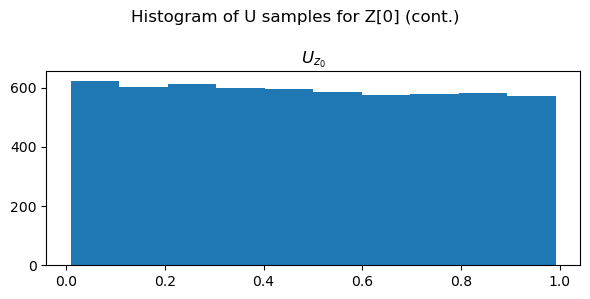

In [23]:
fig, ax = plt.subplots(figsize=(6,3))
fig.suptitle('Histogram of U samples for Z[0] (cont.)')
ax.hist(z_res['u_z_cont'][:,0])
ax.set_title(r'$U_{z_0}$')
plt.tight_layout()
plt.show()

In [24]:
Y = toy_data["Y"]

In [25]:
key, subkey = jr.split(key)
frugal_flow, losses = train_frugal_flow(
    causal_model="location_translation",
    key=subkey,
    y=Y,
    u_z=u_z, 
    learning_rate=1e-2, #5e-3,
    max_epochs=100,
    max_patience=30,
    batch_size=100,
    condition=toy_data["X"],
    causal_model_args={"ate":0.5, "RQS_knots":8, "nn_depth":1, "nn_width":50, "flow_layers":4},
)

 68%|██████▊   | 68/100 [03:38<01:42,  3.22s/it, train=-49.7, val=-43.4 (Max patience reached)]


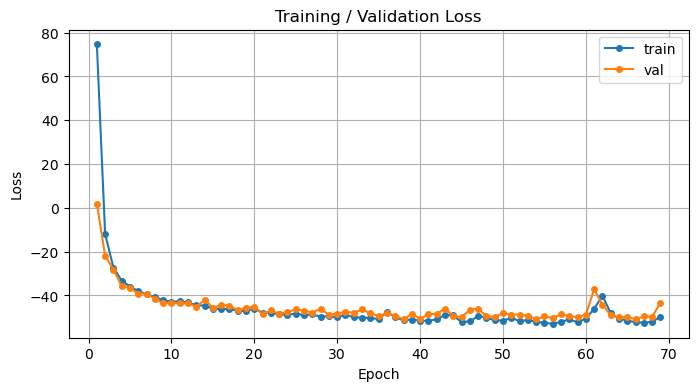

In [28]:
train = np.array(losses['train'])
val = np.array(losses['val'])
epochs = np.arange(1, len(train) + 1)

plt.figure(figsize=(8,4))
plt.plot(epochs, train, label='train', marker='o', markersize=4)
plt.plot(epochs, val, label='val', marker='o', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
import paramax
loccond_block = frugal_flow.bijection.bijections[5]
tau_hat = jnp.array([float(paramax.unwrap(loccond_block.bijections[k]).ate) for k in range(64)])
print(" tau_hat:", tau_hat)

 tau_hat: [0.02705537 0.09857655 0.21946093 0.27169064 0.11332316 0.13567966
 0.02234184 0.10053855 0.10405774 0.12102669 0.15514313 0.15755942
 0.21549405 0.22710285 0.17145054 0.12176999 0.11435565 0.13836573
 0.18892135 0.7951979  0.8009028  0.26226932 0.14047632 0.11664608
 0.11446578 0.15439095 0.7163333  0.66098595 0.6789127  0.7024542
 0.20433705 0.16730997 0.12951368 0.2317675  0.82830644 0.91216534
 0.69561857 0.7202884  0.1381801  0.17175199 0.17451577 0.1507784
 0.1429314  0.7378353  0.88849014 0.07790463 0.19944377 0.7334214
 0.15939578 0.2006349  0.40219915 0.08515338 0.17000134 0.21646026
 0.29085505 0.16562219 0.15390459 0.3040458  0.22350094 0.20988995
 0.21074924 0.18098019 0.20093982 0.09411956]


In [30]:
tau_hat.shape
toy_data["ATE"].shape

(64,)

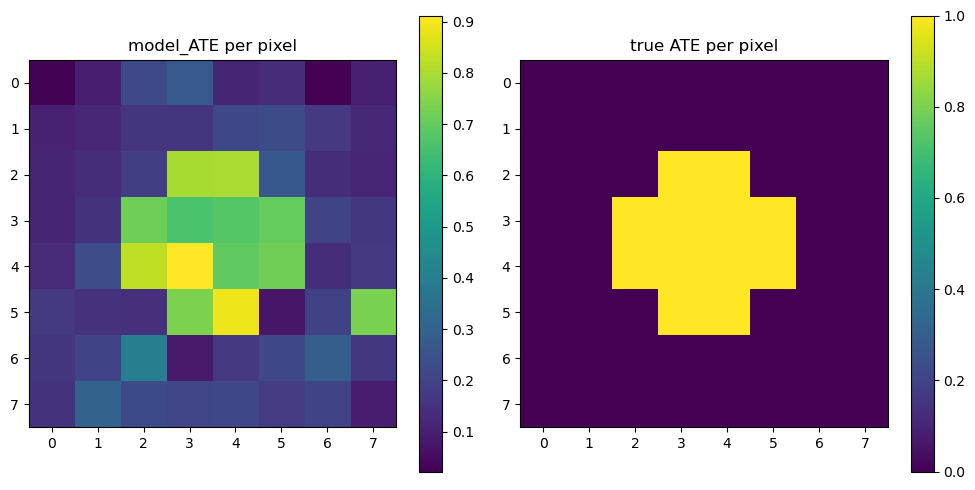

In [31]:
model_ATE = np.asarray(tau_hat)
true_ATE = np.asarray(toy_data["ATE"])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
im0 = axes[0].imshow(model_ATE.reshape(SIZE, SIZE)); axes[0].set_title("model_ATE per pixel")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(true_ATE.reshape(SIZE, SIZE)); axes[1].set_title("true ATE per pixel")
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

## ## Frugal flow flexible continuous arm

The same toy data, fitted with `causal_model="flexible_continuous"` instead of `location_translation`. 

In [32]:
from frugal_flows.interventions import interventional_samples, tau_curve

K = Y.shape[1]                        # 64 pixels
COND_DIM = toy_data["X"].shape[1]     # 1 treatment column

# Same hyperparameters as the location_translation fit above so the two arms are comparable.
key, subkey = jr.split(key)
frugal_flow_flex, losses_flex = train_frugal_flow(
    causal_model="flexible_continuous",
    key=subkey,
    y=Y,
    u_z=u_z,
    learning_rate=1e-2,
    max_epochs=100,
    max_patience=30,
    batch_size=100,
    condition=toy_data["X"],
    causal_model_args={"RQS_knots": 8, "nn_depth": 1, "nn_width": 50, "flow_layers": 4},
)

100%|██████████| 100/100 [03:35<00:00,  2.15s/it, train=-50.7, val=-48.3]


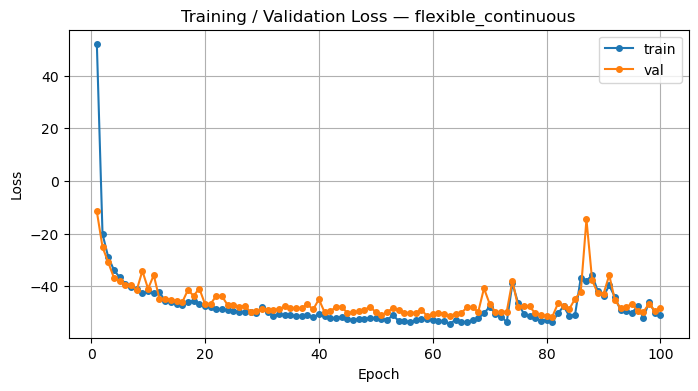

In [33]:
train_f = np.array(losses_flex['train'])
val_f = np.array(losses_flex['val'])
epochs_f = np.arange(1, len(train_f) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_f, train_f, label='train', marker='o', markersize=4)
plt.plot(epochs_f, val_f, label='val', marker='o', markersize=4)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation Loss — flexible_continuous')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
# Paired common-random-number interventional read-out.

N_MC = 5000

readout = interventional_samples(
    jr.key(SEED),
    frugal_flow_flex,
    cond_dim=COND_DIM,
    n_mc=N_MC,
    dim_y=K,
)

tau_hat_flex = np.asarray(readout["ate"])          # (K,) per-pixel ATE
print("tau_hat_flex shape:", tau_hat_flex.shape)
print("any NaN in samples:", readout["anynan"])
print("y0 shape:", readout["y0"].shape, " y1 shape:", readout["y1"].shape)
print("tau_hat_flex range: [%.3f, %.3f]" % (tau_hat_flex.min(), tau_hat_flex.max()))

tau_hat_flex shape: (64,)
any NaN in samples: False
y0 shape: (5000, 64)  y1 shape: (5000, 64)
tau_hat_flex range: [-0.054, 1.041]


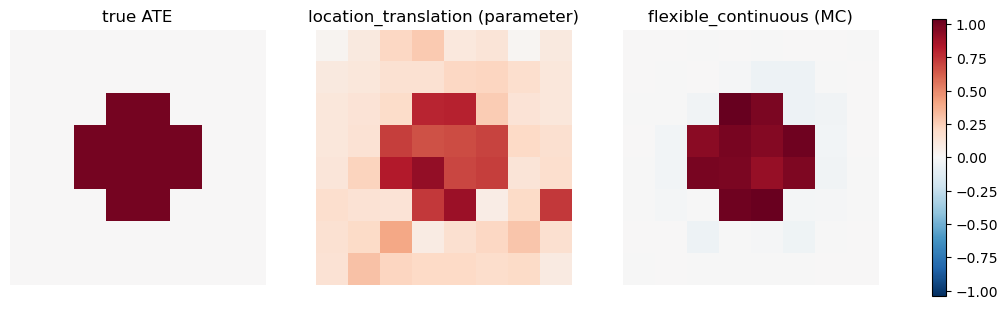

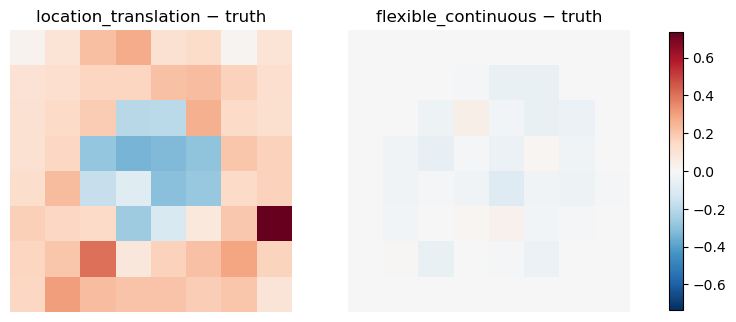

In [35]:
true_ATE = np.asarray(toy_data["ATE"])
tau_hat_loc = np.asarray(tau_hat)                  # location_translation, read off LocCond

# Shared symmetric colour scale so the three panels are actually comparable.
vmax = max(np.abs(true_ATE).max(), np.abs(tau_hat_loc).max(), np.abs(tau_hat_flex).max())
kw = dict(cmap="RdBu_r", vmin=-vmax, vmax=vmax)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, arr, title in zip(
    axes,
    [true_ATE, tau_hat_loc, tau_hat_flex],
    ["true ATE", "location_translation (parameter)", "flexible_continuous (MC)"],
):
    im = ax.imshow(arr.reshape(SIZE, SIZE), **kw)
    ax.set_title(title)
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

# Residual maps, same scale as each other
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
rmax = max(np.abs(tau_hat_loc - true_ATE).max(), np.abs(tau_hat_flex - true_ATE).max())
for ax, arr, title in zip(
    axes,
    [tau_hat_loc - true_ATE, tau_hat_flex - true_ATE],
    ["location_translation − truth", "flexible_continuous − truth"],
):
    im = ax.imshow(arr.reshape(SIZE, SIZE), cmap="RdBu_r", vmin=-rmax, vmax=rmax)
    ax.set_title(title)
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

In [36]:
def ate_scores(est, truth):
    est = np.asarray(est).ravel()
    truth = np.asarray(truth).ravel()
    return {
        "MAE": float(np.abs(est - truth).mean()),
        "RMSE": float(np.sqrt(((est - truth) ** 2).mean())),
        "bias": float((est - truth).mean()),
        "corr": float(np.corrcoef(est, truth)[0, 1]),
    }

# Inside / outside the circle: the truth is base_shift inside and exactly 0 outside,
# so these separate "does it find the effect" from "does it stay quiet elsewhere".
inside = true_ATE > 0

comparison = pd.DataFrame(
    {
        "location_translation": ate_scores(tau_hat_loc, true_ATE),
        "flexible_continuous": ate_scores(tau_hat_flex, true_ATE),
    }
).T
comparison["mean_inside"] = [tau_hat_loc[inside].mean(), tau_hat_flex[inside].mean()]
comparison["mean_outside"] = [tau_hat_loc[~inside].mean(), tau_hat_flex[~inside].mean()]
print("true effect inside circle: %.3f, outside: %.3f"
      % (true_ATE[inside].mean(), true_ATE[~inside].mean()))
comparison

true effect inside circle: 1.000, outside: 0.000


,MAE,RMSE,bias,corr,mean_inside,mean_outside
location_translation,0.189765,0.215092,0.100312,0.917681,0.761458,0.178509
flexible_continuous,0.015692,0.025122,-0.011228,0.998344,0.984071,-0.010144


u grid: (40,)  curves: (40, 64)


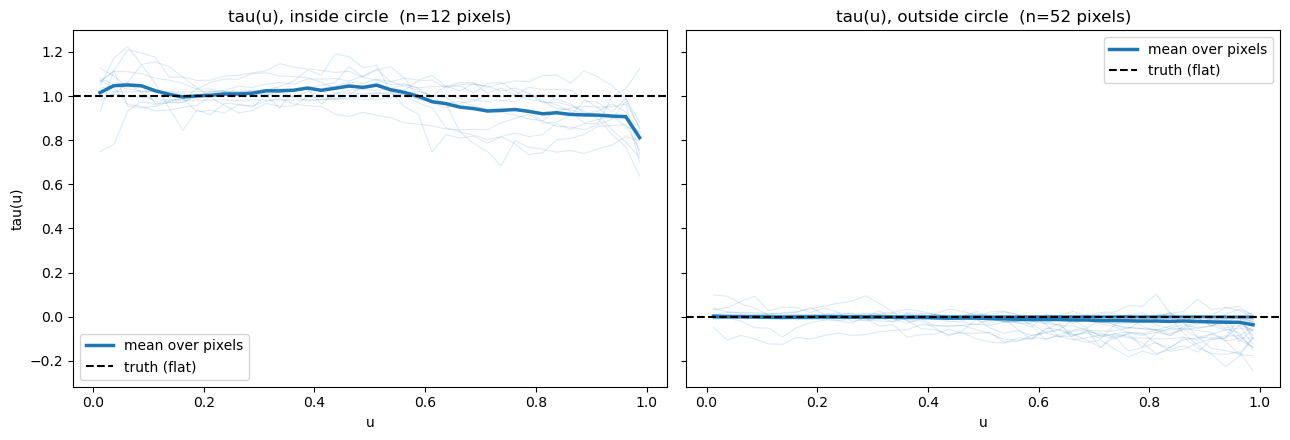

mean over pixels of SD_u[tau(u)]  inside: 0.0837  outside: 0.0170


In [ ]:
# Quantile-resolved effect tau(u) = Q_1(u) - Q_0(u), per pixel.
# The toy effect is a PURE LOCATION SHIFT, so the truth is FLAT in u for every pixel. 
# Any slope or curvature the spline margin shows here is spurious, this is the diagnostic the flexible arm makes available and the additive arm cannot.
u, curves = tau_curve(readout["y0"], readout["y1"])   # curves: (n_bins, K)
print("u grid:", u.shape, " curves:", curves.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, mask, name in zip(axes, [inside, ~inside], ["inside circle", "outside circle"]):
    band = curves[:, mask]
    ax.plot(u, band, color="C0", alpha=0.15, lw=0.8)
    ax.plot(u, band.mean(axis=1), color="C0", lw=2.5, label="mean over pixels")
    ax.axhline(true_ATE[mask].mean(), color="k", ls="--", lw=1.5, label="truth (flat)")
    ax.set_title(f"tau(u), {name}  (n={mask.sum()} pixels)")
    ax.set_xlabel("u")
    ax.legend()
axes[0].set_ylabel("tau(u)")
plt.tight_layout()
plt.show()

# Numerical flatness check: SD of tau across u, averaged over pixels.
# ~0 means the fitted effect really is a location shift.
print("mean over pixels of SD_u[tau(u)]  inside: %.4f  outside: %.4f"
      % (curves[:, inside].std(axis=0).mean(), curves[:, ~inside].std(axis=0).mean()))